# שלב 1 — יצירת דאטה סינטטי

בשלב הזה ניצור דאטה מלאכותי עבור הפרויקט.

כל דוגמה בדאטה תכלול:

1. תמונה של שעון דיגיטלי  
2. תמונה של שעון אנלוגי עם מחוגים  
3. תמונה של אותו שעון אנלוגי בלי מחוגים  
4. קובץ labels.csv עם השעה המתאימה לכל תמונה

In [53]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

## יצירת תיקיות

כאן ניצור את מבנה התיקיות של הדאטה:

- digital — תמונות של שעונים דיגיטליים
- analog_with_hands — שעונים אנלוגיים עם מחוגים
- analog_clean — שעונים אנלוגיים בלי מחוגים
- labels.csv — טבלת התוויות

In [54]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"

DIGITAL_DIR = DATA_DIR / "digital"
ANALOG_WITH_HANDS_DIR = DATA_DIR / "analog_with_hands"
ANALOG_CLEAN_DIR = DATA_DIR / "analog_clean"

for folder in [DIGITAL_DIR, ANALOG_WITH_HANDS_DIR, ANALOG_CLEAN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


## פונקציה ליצירת שעון דיגיטלי

הפונקציה מקבלת שעה, דקה ושנייה, ומחזירה תמונה של שעון דיגיטלי בפורמט:

HH:MM:SS

In [55]:
def create_digital_clock_image(hour, minute, second, image_size=224):
    bg_colors = [
        (5, 5, 5),
        (15, 15, 20),
        (0, 20, 15),
        (20, 10, 10),
        (8, 8, 25)
    ]

    digit_colors = [
        (0, 255, 120),
        (0, 220, 255),
        (255, 80, 80),
        (255, 220, 80),
        (220, 220, 255)
    ]

    frame_colors = [
        (40, 40, 40),
        (80, 80, 80),
        (20, 80, 60),
        (70, 40, 40)
    ]

    img = Image.new("RGB", (image_size, image_size), color=random.choice(bg_colors))
    draw = ImageDraw.Draw(img)

    time_text = f"{hour:02d}:{minute:02d}:{second:02d}"

    font_size = random.choice([34, 36, 38, 40, 42, 44])

    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), time_text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    x = (image_size - text_width) // 2 + random.randint(-4, 4)
    y = (image_size - text_height) // 2 + random.randint(-3, 3)

    rect_y1 = random.randint(65, 78)
    rect_y2 = random.randint(145, 158)

    draw.rounded_rectangle(
        [18, rect_y1, image_size - 18, rect_y2],
        radius=random.choice([8, 12, 16]),
        fill=(0, 0, 0),
        outline=random.choice(frame_colors),
        width=random.choice([2, 3, 4])
    )

    draw.text((x, y), time_text, fill=random.choice(digit_colors), font=font)

    return img

## פונקציות ליצירת שעון אנלוגי

כאן ניצור שעון אנלוגי.

נשתמש בשלוש פונקציות:

1. ציור פני השעון  
2. ציור מחוג לפי זווית  
3. יצירת תמונה מלאה של שעון אנלוגי, עם או בלי מחוגים

In [56]:
ROMAN_NUMERALS = {
    1: "I", 2: "II", 3: "III", 4: "IV",
    5: "V", 6: "VI", 7: "VII", 8: "VIII",
    9: "IX", 10: "X", 11: "XI", 12: "XII"
}


def random_clock_style():
    numeral_type = random.choice(["none", "arabic", "roman"])

    return {
        "background": random.choice([
            (230, 230, 225),
            (245, 238, 220),
            (25, 25, 30),
            (235, 240, 245),
            (250, 250, 250),
            (238, 232, 218)
        ]),
        "face_color": random.choice([
            (245, 245, 240),
            (255, 250, 235),
            (35, 35, 42),
            (250, 250, 255),
            (255, 255, 255),
            (248, 244, 232)
        ]),
        "outline_color": random.choice([
            (20, 20, 20),
            (150, 115, 40),
            (210, 210, 210),
            (40, 80, 120),
            (80, 80, 80),
            (120, 90, 50)
        ]),
        "outline_width": random.choice([2, 3, 4, 5, 6]),

        "mark_color": random.choice([
            (30, 30, 30),
            (120, 85, 30),
            (230, 230, 230),
            (40, 80, 120),
            (90, 90, 90)
        ]),
        "hour_mark_length": random.choice([10, 12, 15, 18, 22]),
        "minute_mark_length": random.choice([4, 5, 6, 8]),
        "hour_mark_width": random.choice([2, 3, 4, 5]),
        "minute_mark_width": random.choice([1, 1, 2]),

        "numeral_type": numeral_type,
        "number_color": random.choice([
            (30, 30, 30),
            (160, 120, 40),
            (240, 240, 240),
            (40, 80, 120),
            (90, 70, 40)
        ]),
        "number_font_size": random.choice([14, 16, 18, 20, 22]),

        "hand_style": random.choice(["simple", "thick", "thin", "modern"]),
        "hour_hand_color": random.choice([
            (20, 20, 20),
            (60, 45, 20),
            (240, 240, 240),
            (20, 40, 70)
        ]),
        "minute_hand_color": random.choice([
            (20, 20, 20),
            (60, 45, 20),
            (240, 240, 240),
            (20, 40, 70)
        ]),
        "second_hand_color": random.choice([
            (200, 0, 0),
            (190, 120, 20),
            (255, 80, 80),
            (30, 120, 200)
        ]),
        "show_second_hand": random.choice([True, True, False]),

        "center_dot_size": random.choice([4, 5, 6, 7])
    }


def draw_clock_face(draw, center, radius, style):
    cx, cy = center

    draw.ellipse(
        [cx - radius, cy - radius, cx + radius, cy + radius],
        outline=style["outline_color"],
        width=style["outline_width"],
        fill=style["face_color"]
    )

    for i in range(60):
        angle = math.radians(i * 6 - 90)

        if i % 5 == 0:
            inner = radius - style["hour_mark_length"]
            width = style["hour_mark_width"]
        else:
            inner = radius - style["minute_mark_length"]
            width = style["minute_mark_width"]

        x1 = cx + inner * math.cos(angle)
        y1 = cy + inner * math.sin(angle)
        x2 = cx + radius * math.cos(angle)
        y2 = cy + radius * math.sin(angle)

        draw.line([x1, y1, x2, y2], fill=style["mark_color"], width=width)

    if style["numeral_type"] != "none":
        try:
            font = ImageFont.truetype("arial.ttf", style["number_font_size"])
        except:
            font = ImageFont.load_default()

        for number in range(1, 13):
            angle = math.radians(number * 30 - 90)
            number_radius = radius - 32

            if style["numeral_type"] == "roman":
                text = ROMAN_NUMERALS[number]
            else:
                text = str(number)

            bbox = draw.textbbox((0, 0), text, font=font)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]

            x = cx + number_radius * math.cos(angle) - tw / 2
            y = cy + number_radius * math.sin(angle) - th / 2

            draw.text((x, y), text, fill=style["number_color"], font=font)


def draw_hand(draw, center, angle_deg, length, color, width, style_name="simple"):
    cx, cy = center
    angle = math.radians(angle_deg - 90)

    x = cx + length * math.cos(angle)
    y = cy + length * math.sin(angle)

    if style_name == "thin":
        draw.line([cx, cy, x, y], fill=color, width=max(1, width - 2))

    elif style_name == "thick":
        draw.line([cx, cy, x, y], fill=color, width=width + 2)

    elif style_name == "modern":
        back_length = 12
        bx = cx - back_length * math.cos(angle)
        by = cy - back_length * math.sin(angle)
        draw.line([bx, by, x, y], fill=color, width=width)

    else:
        draw.line([cx, cy, x, y], fill=color, width=width)


def create_analog_clock_image(hour, minute, second, image_size=224, with_hands=True, style=None):
    if style is None:
        style = random_clock_style()

    img = Image.new("RGB", (image_size, image_size), color=style["background"])
    draw = ImageDraw.Draw(img)

    center = (image_size // 2, image_size // 2)
    radius = random.choice([80, 84, 88, 90, 94])

    draw_clock_face(draw, center, radius, style)

    if with_hands:
        hour_angle = ((hour % 12) + minute / 60) * 30
        minute_angle = (minute + second / 60) * 6
        second_angle = second * 6

        draw_hand(
            draw, center, hour_angle,
            random.choice([42, 45, 48]),
            style["hour_hand_color"],
            random.choice([4, 5, 6]),
            style["hand_style"]
        )

        draw_hand(
            draw, center, minute_angle,
            random.choice([60, 64, 68]),
            style["minute_hand_color"],
            random.choice([2, 3, 4]),
            style["hand_style"]
        )

        if style["show_second_hand"]:
            draw_hand(
                draw, center, second_angle,
                random.choice([70, 74, 78]),
                style["second_hand_color"],
                random.choice([1, 2]),
                "thin"
            )

        dot = style["center_dot_size"]
        cx, cy = center
        draw.ellipse(
            [cx - dot, cy - dot, cx + dot, cy + dot],
            fill=style["hour_hand_color"]
        )

    return img

בדיקה על דוגמה אחת

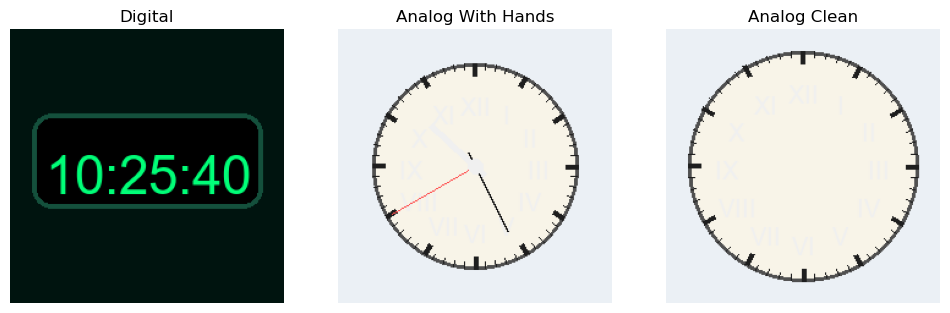

In [57]:
hour, minute, second = 10, 25, 40

digital_img = create_digital_clock_image(hour, minute, second)

style = random_clock_style()

analog_hands_img = create_analog_clock_image(
    hour, minute, second,
    with_hands=True,
    style=style
)

analog_clean_img = create_analog_clock_image(
    hour, minute, second,
    with_hands=False,
    style=style
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(digital_img)
plt.title("Digital")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(analog_hands_img)
plt.title("Analog With Hands")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(analog_clean_img)
plt.title("Analog Clean")
plt.axis("off")

plt.show()

יצירת הדאטה המלא- יוצרים 1000 דוגמאות כאלה

In [58]:
NUM_SAMPLES = 1000

records = []

for sample_id in range(NUM_SAMPLES):
    hour = random.randint(0, 23)
    minute = random.randint(0, 59)
    second = random.randint(0, 59)

    # Digital clock image
    digital_img = create_digital_clock_image(
        hour,
        minute,
        second
    )

    # One shared style for both analog images
    # so they are exactly the same clock
    style = random_clock_style()

    # Analog clock with hands
    analog_hands_img = create_analog_clock_image(
        hour,
        minute,
        second,
        with_hands=True,
        style=style
    )

    # Clean analog clock (same style, no hands)
    analog_clean_img = create_analog_clock_image(
        hour,
        minute,
        second,
        with_hands=False,
        style=style
    )

    # Save paths
    digital_path = DIGITAL_DIR / f"digital_{sample_id:05d}.png"
    analog_hands_path = ANALOG_WITH_HANDS_DIR / f"analog_hands_{sample_id:05d}.png"
    analog_clean_path = ANALOG_CLEAN_DIR / f"analog_clean_{sample_id:05d}.png"

    # Save images
    digital_img.save(digital_path)
    analog_hands_img.save(analog_hands_path)
    analog_clean_img.save(analog_clean_path)

    # Save metadata
    records.append({
        "sample_id": sample_id,
        "digital_image_path": str(digital_path),
        "analog_with_hands_path": str(analog_hands_path),
        "analog_clean_path": str(analog_clean_path),
        "hour": hour,
        "minute": minute,
        "second": second
    })

# Create labels dataframe
labels_df = pd.DataFrame(records)

LABELS_PATH = DATA_DIR / "labels.csv"
labels_df.to_csv(LABELS_PATH, index=False)

print("Number of samples:", len(labels_df))
labels_df.head()

Number of samples: 1000


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,15,38,21
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,1,8,27
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,5,5,2
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,9,7,39
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,8,3,48


Total samples: 1000
   sample_id                            digital_image_path  \
0          0  clock_project\data\digital\digital_00000.png   
1          1  clock_project\data\digital\digital_00001.png   
2          2  clock_project\data\digital\digital_00002.png   
3          3  clock_project\data\digital\digital_00003.png   
4          4  clock_project\data\digital\digital_00004.png   

                              analog_with_hands_path  \
0  clock_project\data\analog_with_hands\analog_ha...   
1  clock_project\data\analog_with_hands\analog_ha...   
2  clock_project\data\analog_with_hands\analog_ha...   
3  clock_project\data\analog_with_hands\analog_ha...   
4  clock_project\data\analog_with_hands\analog_ha...   

                                   analog_clean_path  hour  minute  second  
0  clock_project\data\analog_clean\analog_clean_0...    15      38      21  
1  clock_project\data\analog_clean\analog_clean_0...     1       8      27  
2  clock_project\data\analog_clean\anal

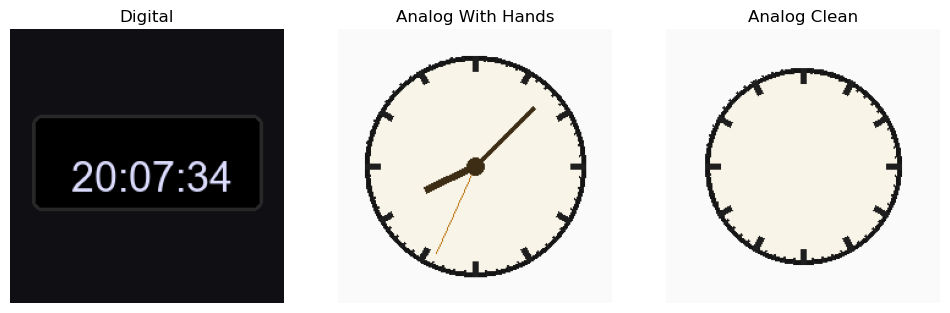

In [59]:
df = pd.read_csv(DATA_DIR / "labels.csv")

print("Total samples:", len(df))
print(df.head())

sample = df.sample(1).iloc[0]

digital_img = Image.open(sample["digital_image_path"])
analog_hands_img = Image.open(sample["analog_with_hands_path"])
analog_clean_img = Image.open(sample["analog_clean_path"])

print(f'Time: {sample["hour"]:02d}:{sample["minute"]:02d}:{sample["second"]:02d}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(digital_img)
plt.title("Digital")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(analog_hands_img)
plt.title("Analog With Hands")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(analog_clean_img)
plt.title("Analog Clean")
plt.axis("off")

plt.show()